In [119]:
import json 
import pandas as pd 
pd.options.mode.chained_assignment = None  # default='warn'
import seaborn as sns 
import numpy as np
import glob
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from matplotlib.markers import MarkerStyle
from matplotlib.patches import Ellipse
import scipy.stats
from sklearn import metrics
import pickle
import sys

from config import home_path, llm_review_path, supp_table_path

sys.path.insert(1,home_path) 

from common_functions import entropy, mean_confidence_interval, format_p, read_fasta, sort_dict_by_value

In [120]:
regular_aas = ['P','S','L','A','V','G','T','E','R','Q','D','F','I','H','Y','N','K','C','W','M']

def augment_masked_df_with_site_entropy(df, limit_normal_aas = True, return_entropy = True):
    df["name"] = df["ref_aa"] + df["aa_pos"].astype(str) + df["token_str"]
    df = df.loc[df["token_str"].isin(regular_aas)]
    variant_to_s1 = {}
    variant_to_adj_prob = {}
    variant_to_site_entropy = {}
    for pos, sub_df in df.groupby("aa_pos"):
        v_to_adj_score = {}
        valid_prob_total = np.sum(sub_df["score"])
        for index, row in sub_df.iterrows():
            v_to_adj_score[row["name"]] = row["score"] / valid_prob_total
        
        sub_df["adj_score"] = sub_df["name"].apply(lambda x : v_to_adj_score[x])
        
        wt_val = sub_df.loc[sub_df["ref_aa"] == sub_df["token_str"]]
        assert len(wt_val) == 1
        wt_score = wt_val.iloc[0]["adj_score"]
        
        adj_prob_list = []
        for index, row in sub_df.iterrows():
            variant_to_s1[row["name"]] = np.log(row["adj_score"]) - np.log(wt_score)
            variant_to_adj_prob[row["name"]] = row["adj_score"] / valid_prob_total
            adj_prob_list.append(row["adj_score"] / valid_prob_total)
        ent_val = entropy(adj_prob_list)
        
        for name in sub_df["name"].values: variant_to_site_entropy[name] = ent_val

    if return_entropy:
        df["site_entropy"] = df["name"].apply(lambda x : variant_to_site_entropy[x])
            
    df["s1"] = df["name"].apply(lambda x : variant_to_s1[x])
    df["adj_score"] = df["name"].apply(lambda x : variant_to_adj_prob[x])
    
    df = df.set_index("name")
    return df


7260
403
403
403
403
4.167858892852742


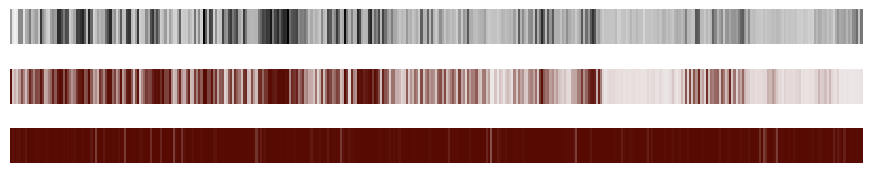

In [121]:
model_1 = "esm_2_15B"
model_2 = "esm_2_150M"

pal1 = sns.light_palette("black", as_cmap=True, reverse = True)
pal2 = sns.light_palette("#570a02", as_cmap=True, reverse = True)


path_1 = llm_review_path + "data/ProteinGym_substitutions/"
exp = "PTEN_HUMAN_Mighell_2018"
gene = "PTEN_HUMAN"

fig, (ax1,ax2, ax3) = plt.subplots(3,1,figsize=(11,2))
fig.subplots_adjust(hspace = 0.7)


# protein_gym = pd.read_csv("/Genomics/singhlab/LLM_review/data/ProteinGym_reference_file_substitutions.csv")
 
dms_df = pd.read_csv(path_1 + exp + ".csv")
# getting only single aa subs 
dms_df = dms_df.loc[~dms_df["mutant"].str.contains(":")]
dms_df["ref"] = dms_df["mutant"].apply(lambda x : x[0])
dms_df["alt"] = dms_df["mutant"].apply(lambda x : x[-1])
dms_df["pos"] = dms_df["mutant"].apply(lambda x : int(x[1:-1])) 
dms_df = dms_df.loc[dms_df["ref"]!= dms_df["alt"]]

dms_df.drop_duplicates(subset = "mutant")

print(len(dms_df))

x1 = []
y1 = []

for pos, sub_df in dms_df.groupby("pos"):
    x1.append(pos)
    y1.append(np.mean(sub_df[ "DMS_score"]))
    
print(len(y1))
sns.heatmap([y1], ax = ax1,cmap = pal1, cbar = False)


df1 = pd.read_csv(llm_review_path + "masked_results/protein_gym/" + model_1 + "/" + gene + ".csv.gz")
df1 = augment_masked_df_with_site_entropy(df1)

x2 = []
y2 = []
for pos, sub_df in df1.groupby("aa_pos"):
    x2.append(pos)
    y2.append(np.mean(sub_df.iloc[0]["site_entropy"]))
sns.heatmap([y2], ax = ax3,cmap = pal2, vmax=np.log2(20), vmin = 0, cbar = False)


df2 = pd.read_csv(llm_review_path + "masked_results/protein_gym/" + model_2 + "/" + gene + ".csv.gz")
df2 = augment_masked_df_with_site_entropy(df2)
x3 = []
y3 = []

for pos, sub_df in df2.groupby("aa_pos"):
    x3.append(pos)
    y3.append(np.mean(sub_df.iloc[0]["site_entropy"]))
sns.heatmap([y3], ax = ax2, cmap = pal2, vmax=np.log2(20), vmin = 0, cbar = False)

print(len(y1))
print(len(y2))
print(len(y3))
print(np.max(y3))
ax1.get_xaxis().set_visible(False)
ax2.get_xaxis().set_visible(False)
ax3.get_xaxis().set_visible(False)

ax1.get_yaxis().set_visible(False)
ax2.get_yaxis().set_visible(False)
ax3.get_yaxis().set_visible(False)

# ax1.figure.colorbar(pal1)

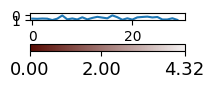

In [122]:
# create dummy invisible image
# (use the colormap you want to have on the colorbar)
fig, ax = plt.subplots(figsize = (2,2))
img = plt.imshow(np.array([[0,np.log2(20)]]), cmap=pal2)
img.set_visible(False)

cb=plt.colorbar(orientation="horizontal", ticks = [0,2,4.32])
cb.ax.tick_params(labelsize=13)

# add any other things you want to the figure.
plt.plot(np.random.rand(30))

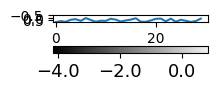

In [123]:
fig, ax = plt.subplots(figsize = (2,2))
img = plt.imshow(np.array([[np.min(y1),np.max(y1)]]), cmap=pal1)
img.set_visible(False)

cb = plt.colorbar(orientation="horizontal", ticks = [-4,-2,0,2.5])

cb.ax.tick_params(labelsize=13)

# add any other things you want to the figure.
plt.plot(np.random.rand(30))

(403, 20)
(10, 20)


[Text(0, 0.5, '50'),
 Text(0, 1.5, '51'),
 Text(0, 2.5, '52'),
 Text(0, 3.5, '53'),
 Text(0, 4.5, '54'),
 Text(0, 5.5, '55'),
 Text(0, 6.5, '56'),
 Text(0, 7.5, '57'),
 Text(0, 8.5, '58'),
 Text(0, 9.5, '59')]

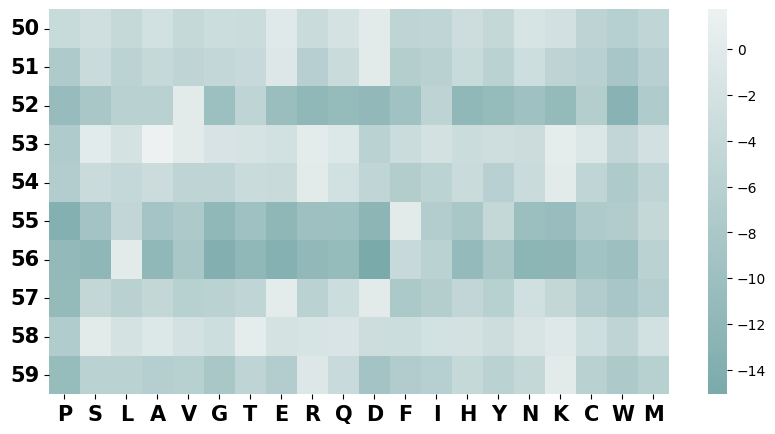

In [124]:
path_1 = llm_review_path + "data/ProteinGym_substitutions/"
exp = "PTEN_HUMAN_Mighell_2018"
gene = "PTEN_HUMAN"


regular_aas = ['P','S','L','A','V','G','T','E','R','Q','D','F','I','H','Y','N','K','C','W','M']

gene = "PTEN_HUMAN"
df1 = pd.read_csv(llm_review_path + "masked_results/protein_gym/" + "esm_2_150M" + "/" + gene + ".csv.gz")
df1 = augment_masked_df_with_site_entropy(df1)
impact_matrix = []

for pos, sub_df in  df1.groupby("aa_pos"):
    lst = []
    impact_dict = dict(zip(sub_df["token_str"].values, sub_df["s1"].values))
    for aa in regular_aas:
        lst.append(impact_dict[aa])
    impact_matrix.append(lst)
    
    
impact_matrix = np.asarray(impact_matrix)
print(np.shape(impact_matrix))

begin_pos = 50
end_pos = 60


subset = impact_matrix[begin_pos:end_pos, :]
print(np.shape(subset))

pal3 = sns.light_palette("#7baaab", as_cmap=True, reverse = True)


fig, ax = plt.subplots(figsize = (10,5), )
sns.heatmap(subset, ax = ax, cmap = pal3)

ax.set_xticklabels(regular_aas, rotation = 0, fontsize = 15, fontweight = "bold")

ax.set_yticklabels(range(begin_pos, end_pos), rotation = 0 , fontsize = 15, fontweight = "bold")

(403, 20)
(10, 20)


[Text(0, 0.5, '50'),
 Text(0, 1.5, '51'),
 Text(0, 2.5, '52'),
 Text(0, 3.5, '53'),
 Text(0, 4.5, '54'),
 Text(0, 5.5, '55'),
 Text(0, 6.5, '56'),
 Text(0, 7.5, '57'),
 Text(0, 8.5, '58'),
 Text(0, 9.5, '59')]

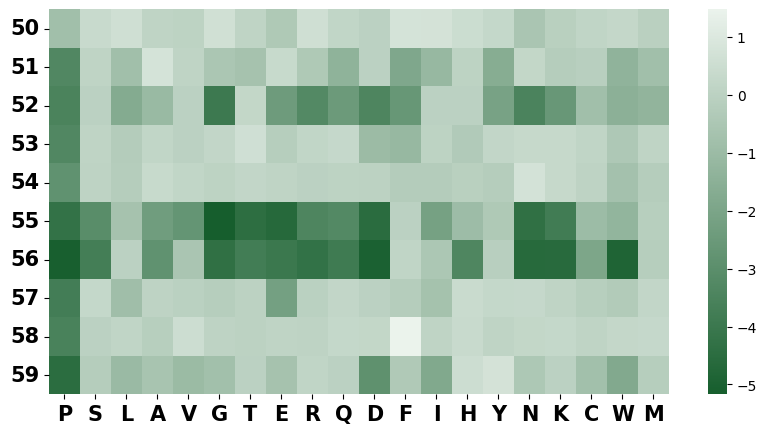

In [125]:
dms_df = pd.read_csv(path_1 + exp + ".csv")
# getting only single aa subs 
dms_df = dms_df.loc[~dms_df["mutant"].str.contains(":")]
dms_df["ref"] = dms_df["mutant"].apply(lambda x : x[0])
dms_df["alt"] = dms_df["mutant"].apply(lambda x : x[-1])
dms_df["pos"] = dms_df["mutant"].apply(lambda x : int(x[1:-1])) 
dms_df = dms_df.loc[dms_df["ref"]!= dms_df["alt"]]

dms_df = dms_df.drop_duplicates(subset = "mutant")


impact_matrix = []

for pos, sub_df in  dms_df.groupby("pos"):
    lst = []
    impact_dict = dict(zip(sub_df["alt"].values, sub_df["DMS_score"].values))
    for aa in regular_aas:
        lst.append(impact_dict[aa] if aa in impact_dict.keys() else 0)
    impact_matrix.append(lst)
    
    
impact_matrix = np.asarray(impact_matrix)
print(np.shape(impact_matrix))

begin_pos = 50
end_pos = 60


subset = impact_matrix[begin_pos:end_pos, :]
print(np.shape(subset))

pal4 = sns.light_palette("#165e2d", as_cmap=True, reverse = True)


fig, ax = plt.subplots(figsize = (10,5))
sns.heatmap(subset, ax = ax, cmap = pal4)

ax.set_xticklabels(regular_aas, rotation = 0, fontsize = 15, fontweight = "bold")

ax.set_yticklabels(range(begin_pos, end_pos) , rotation = 0, fontsize = 15, fontweight = "bold")

In [126]:
results_df = pd.read_csv(supp_table_path + "supp_table_alpha.csv")


model_to_task_median = {}

for task, task_df in results_df.groupby("Task"):
    model_to_task_median[task] = {}
    for model, sub_df in task_df.groupby("Model"):
        model_to_task_median[task][model] = np.median(sub_df["Performance"].values)
        
res_df = pd.DataFrame(model_to_task_median)

res_df = res_df.sort_values(by = ["DMS"], ascending = False)
res_df["DMS_rank"] = list(range(1, len(res_df)  +1))


res_df = res_df.sort_values(by = ["Site Conservation Estimation"], ascending = False)
res_df["conservation_rank"] = list(range(1, len(res_df)  +1))

res_df = res_df.sort_values(by = ["Catalytic Site Identification"], ascending = False)
res_df["catalytic_rank"] = list(range(1, len(res_df)  +1))

res_df = res_df[["DMS_rank", "conservation_rank", "catalytic_rank"]]
res_df["average_rank"] = res_df.mean(axis = 1)
res_df = res_df.sort_values(by = "average_rank")

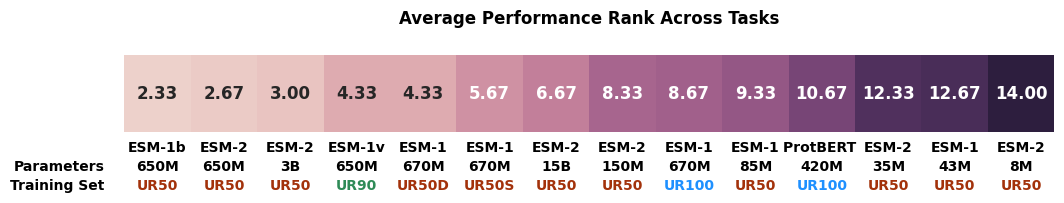

In [127]:
from matplotlib.colors import LinearSegmentedColormap



model_info = pd.read_csv("model_info.txt", delimiter = "\t")

model_info["shorthand_name"] = [
    "esm_1_43M",
    "esm_1_85M",
    "esm_1b",
    "esm_1_UR100",
    "esm_1_UR50D",
    "esm_1_UR50",
    "esm_1v",
    "esm_2",
    "esm_2_150M",
    "esm_2_15B",
    "esm_2_35M",
    "esm_2_650M",
    "esm_2_8M",
    "protbert",
    "protbert_bfd"
]

model_to_my_string = {
    "ESM-1 (43M)": "esm_1_43M",
    "ESM-1 (85M)": "esm_1_85M",
    "ESM-1 (670M) UR100": "esm_1_UR100",
    "ESM-1 (670M) UR50S": "esm_1_UR50",
    "ESM-1 (670M) UR50D": "esm_1_UR50D",
    "ESM-1b": "esm_1b",
    "ESM-1v": "esm_1v",
    "ESM-2 (150M)": "esm_2_150M",
    "ESM-2 (15B)":"esm_2_15B",
    "ESM-2 (35M)":"esm_2_35M",
    "ESM-2 (3B)":"esm_2",
    "ESM-2 (650M)":"esm_2_650M",
    "ESM-2 (8M)":"esm_2_8M",
    "ProtBERT":"protbert"
}

model_to_base_string = dict(zip(model_info["shorthand_name"].values, model_info["base_string"].values))
model_to_params_string = dict(zip(model_info["shorthand_name"].values, model_info["params_string"].values))
model_to_dataset_string = dict(zip(model_info["shorthand_name"].values, model_info["dataset_string"].values))
model_to_model_identifier = dict(zip(model_info["shorthand_name"].values, model_info["model_string"].values))
ur_50_models = ["esm_1_43M", "esm_1_85M", "esm_1_UR50", "esm_1_UR50D", "esm_1b", "esm_2_8M", "esm_2_35M", "esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B"]
ur_100_models = ["esm_1_UR100", "protbert"]
ur_90_models = ["esm_1v"]

model_to_color = {}
ur_50_color = "#A3320B"
ur_90_color =  "#2E8B57" # seagreen
ur_100_color =  "#1E90FF" # "dodgerblue" 

for m in ur_50_models : model_to_color[m] = ur_50_color
for m in ur_100_models : model_to_color[m] = ur_100_color
for m in ur_90_models : model_to_color[m] = ur_90_color


# my_cmap = LinearSegmentedColormap.from_list("dark_orange", ["#ffffff", "darkorange"])



my_cmap = sns.color_palette("flare", as_cmap=True)
my_cmap = sns.cubehelix_palette(as_cmap=True)


fig, ax = plt.subplots(figsize = (12,1))

sns.heatmap(
    [res_df["average_rank"].values], 
    annot = True, 
    fmt=".2f", 
    ax = ax, 
    cbar = False, 
    cmap=my_cmap,
    annot_kws={"weight": "bold", "size" : 12} 
)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title("Average Performance Rank Across Tasks", y = 1.3, fontweight = "bold")

ax.text(-0.3, 1.5, "Parameters", horizontalalignment = "right", fontsize = 10, fontweight = "bold")
ax.text(-0.3, 1.75, "Training Set", horizontalalignment = "right", fontsize = 10, fontweight = "bold" )


for i, name in enumerate(res_df.index.values):
    ax.text(i+0.5, 1.5, model_to_params_string[model_to_my_string[name]].replace("-", ""),fontsize = 10, horizontalalignment= "center", fontweight = "bold")
    ax.text(i+0.5, 1.75, model_to_dataset_string[model_to_my_string[name]].replace("-", ""),fontsize = 10, horizontalalignment= "center", fontweight = "bold", color = model_to_color[model_to_my_string[name]])
    ax.text(i+0.5, 1.25, model_to_base_string[model_to_my_string[name]],fontsize = 10, horizontalalignment= "center", fontweight = "bold")
    
    

Text(0.5, 1.0, 'DMS Proteins')

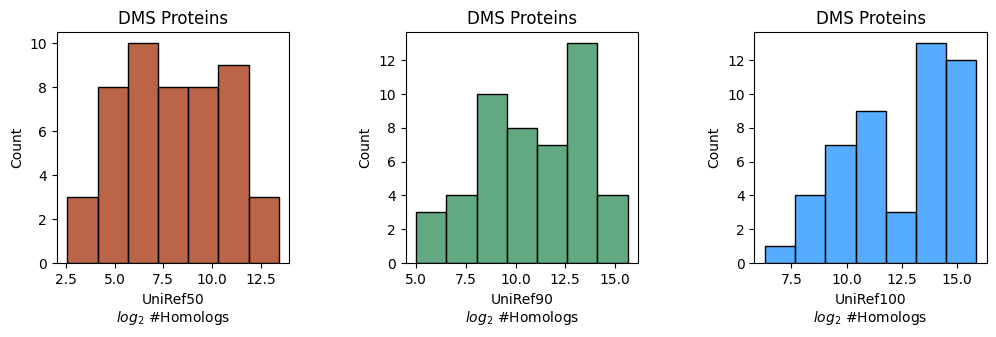

In [165]:


df = pd.read_csv(supp_table_path + "supp_table_zeta.csv")

dms = df.loc[df["Task"] == "DMS"]

fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize = (12,3))

fig.subplots_adjust(wspace = 0.5)

ax = ax1
lst = dms["UniRef50"].values
sns.histplot(np.log2(lst), color = ur_50_color, ax = ax)
ax.set_xlabel("UniRef50\n" + r"$log_2$ #Homologs")
ax.set_title("DMS Proteins")

ax = ax2
lst = dms["UniRef90"].values
sns.histplot(np.log2(lst), color = ur_90_color, ax = ax)
ax.set_xlabel("UniRef90\n" + r"$log_2$ #Homologs")
ax.set_title("DMS Proteins")


ax = ax3
lst = dms["UniRef100"].values
sns.histplot(np.log2(lst), color = ur_100_color, ax = ax)
ax.set_xlabel("UniRef100\n" + r"$log_2$ #Homologs")
ax.set_title("DMS Proteins")






3.906890595608519

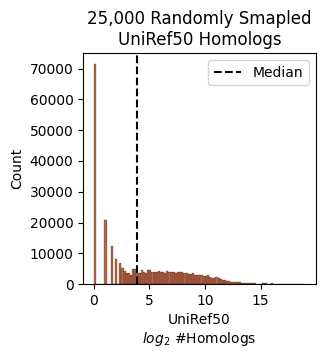

In [164]:
df = pd.read_csv(supp_table_path + "orphanage_pcs_homologs_seqeunces_all_models_all_pooling.csv")


fig, ax = plt.subplots(figsize = (3,3))

lst = df["log_2 UR50 homologs"]

sns.histplot(lst, color = ur_50_color, ax = ax)

ax.set_title("25,000 Randomly Smapled\nUniRef50 Homologs")
ax.set_xlabel("UniRef50\n" + r"$log_2$ #Homologs")

ax.axvline(x = np.median(lst), color = "black", linestyle = "--", label = "Median")

ax.legend(loc = "upper right")
np.median(lst)

In [156]:
df

,Unnamed: 0,model,embedding_type,name,log_2 UR50 homologs,orphanage_distance,PC1,PC2,sequence,full_identifier
0,50000,ESM-2 (150M),mean_pooled,UniRef50_I1BGZ9,6.475733,0.069578,-0.877326,-0.910261,MSFQQHLEQHLSNISKDTTFNVYNLNSNLSKCSSPLIKKSSDDTYL...,UniRef50_I1BGZ9 Cluster: Histone acetyltransfe...
1,50001,ESM-2 (150M),mean_pooled,UniRef50_A0A370APN1,6.845490,0.091235,0.290465,-0.755771,MKFCILILSGLIMFSCAATRVDTSADSKINQQSVVQTVFDNSALYQ...,UniRef50_A0A370APN1 Cluster: Uncharacterized p...
2,50002,ESM-2 (150M),mean_pooled,UniRef50_A0A7L3GL52,8.312883,0.138517,0.494840,1.062325,AAMSGLVVGEAGGHAEKQPDSLDLLERCGVCRERLRAEREPRLLPC...,UniRef50_A0A7L3GL52 Cluster: TIF1B factor (Fra...
3,50003,ESM-2 (150M),mean_pooled,UniRef50_A0A832H6K0,14.792028,0.187409,1.212288,0.850855,MANKFGTPGNDTLFGTSTDDSLFGMAGNDLLDGETGGSDTLDGGDG...,UniRef50_A0A832H6K0 Cluster: Calcium-binding p...
4,50004,ESM-2 (150M),mean_pooled,UniRef50_UPI00129A4DC3,1.584963,0.096675,0.556151,-0.576481,MNNKYLTRAAISLSAALAISACAVTAGNSNLATPPPAEPQRVAPIF...,UniRef50_UPI00129A4DC3 Cluster: metallophospho...
...,...,...,...,...,...,...,...,...,...,...
299995,174995,ESM-2 (8M),CLS,UniRef50_A0A1A9UDK4,3.000000,0.055430,-0.877400,-0.226858,MSVAAELKIVMRVNRNCLSTTAYMKHRKAELKQRLVEHLEKEREDL...,UniRef50_A0A1A9UDK4 Cluster: Uncharacterized p...
299996,174996,ESM-2 (8M),CLS,UniRef50_UPI0009FD4630,7.426265,0.080696,0.638928,-0.750221,MKDTIQNFTGAFLKKECARVILTGAGTSAFAGSSIAHFLKNKTNIR...,UniRef50_UPI0009FD4630 Cluster: SIS domain-con...
299997,174997,ESM-2 (8M),CLS,UniRef50_A0A523VHV8,10.087463,0.064719,-0.598950,-0.975067,MVVHNGNPQKKALIKGGHEKVIQARLEDGEFYFKEDTRQKLSSRVS...,UniRef50_A0A523VHV8 Cluster: Glycine--tRNA lig...
299998,174998,ESM-2 (8M),CLS,UniRef50_A0A0M1W719,1.000000,0.042967,-0.462126,-0.297654,MIYFPYNEEMCSYTDTWMGELYENEYPLVSKGYGQE,UniRef50_A0A0M1W719 Cluster: Uncharacterized p...
